# Pattern Matching 4 - Video, Matching & Tracking

**Objectives**

* Analyze video sequences
* Match objects between frames for tracking

## Video import

[Download](https://my.pcloud.com/publink/show?code=XZpIUMkZQX7lwSh8BPpO5vF6UWC6xSXgVLRy) the images from the video sequence, and the supervised segmentation ground truth: 

(Reference: http://groups.inf.ed.ac.uk/f4k/PAPERS/VIGTA2012.pdf)

Frame shape: (480, 640, 3)    GT unique values: [  0 255]


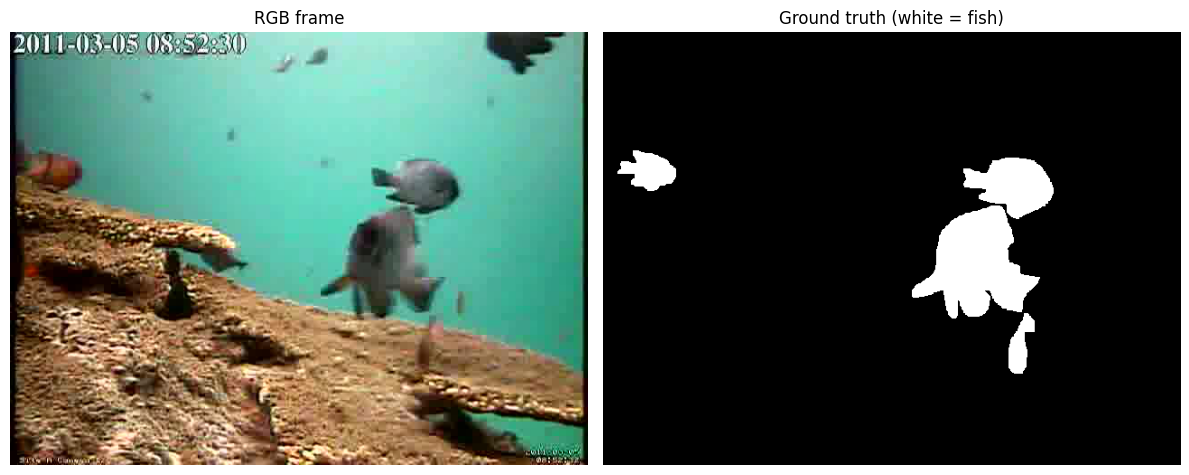

In [77]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from skimage.io import imread
import os

vid_path = '/Users/alice/Desktop/INFO-H501 - Pattern/PR4/video_data/Video/'
gt_path = '/Users/alice/Desktop/INFO-H501 - Pattern/PR4/video_data/GroundTruth/'

seq0 = list(range(685, 706))
seq1 = list(range(1173, 1192))

"""for no in range(*seq1):
    fid = os.path.join(vid_path,'frame%04d.jpg'%no)
    rgb = imread(fid)    
    
    fid =  os.path.join(gt_path,'%d.png'%no)
    supervision = imread(fid)
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.title('rgb image')
    plt.imshow(rgb)
    plt.subplot(1,2,2)
    plt.imshow(supervision)
    plt.title('ground truth')
    break #stop after one frame for test purpose"""

rgb = imread(os.path.join(vid_path, f'frame{seq1[0]:04d}.jpg'))
gt  = imread(os.path.join(gt_path,  f'{seq1[0]}.png'))
print('Frame shape:', rgb.shape, '   GT unique values:', np.unique(gt))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rgb);          axes[0].set_title('RGB frame'); axes[0].axis('off')
axes[1].imshow(gt, cmap='gray'); axes[1].set_title('Ground truth (white = fish)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## Background image (Video segmentation)

When analyzing video sequences, we can use the *movement of the frame* to help our object segmentation. In this video, our goal is to segment the fish from the background. The background here is the part of the image that doesn't change from frame to frame: detecting the objects can therefore be done using **background subtraction**. -> Fish are moving objects whereas the background is mostly static.

Implement the background subtraction algorithm:

1. Initialize background image: $B_{0} = I_{0}$ where $I_t$ is the image at time $t$ and $B$ is the estimated background. 
1. Update background: $B_{t} = \alpha B_{t-1} + (1-\alpha) I_t$
> What is the purpose of $\alpha$? How can you determine that your background estimation is "stable" and can be used?
$\alpha$ = exponential moving average -> when close to 1, background changes slowly, useful for nearly static scene (very slow update thus the background barely reacts to a fish moving through). We tend to remove moving object from the foreground. 

1. Subtract background to detect foreground: $F_t = I_t - B_t$
1. Find a good post-processing to clean-up the foreground image. Label the individual objects (fish).
1. Using the supervised part of the sequence, estimate the detection error of your algorithm.
> *Hint: useful metrics for segmentation performance include per-pixel accuracy, precision, recall, or F1-score (DICE). These measures can also be made per-object, which is slightly more difficult to compute but in many applications a better indicator of the actual performance of the algorithm.*

Background ready


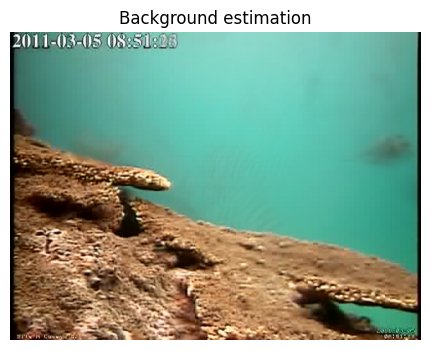

In [78]:
alpha = 0.99 # barely reacts to moving objects 

# B initalized with first frame
B = imread(os.path.join(vid_path, 'frame0001.jpg')).astype(np.float32)

# Background estimation loop on all frames before our sequences of interest (1 to 684) to ensure 
# clean background before the appearance of any fish
for i in range(2, seq0[0]):
    I = imread(os.path.join(vid_path, 'frame%04d.jpg' % i)).astype(np.float32)
    B = alpha * B + (1 - alpha) * I  # Update the background

print('Background ready')

# Visualization
plt.figure(figsize=(6,4))
plt.imshow(B.astype(np.uint8))
plt.title('Background estimation')
plt.axis('off')
plt.show()

## Foreground detection & Threshold 

We can use the foregound score per pixel and afterwards define a threshold of what will be considered as foreground or background. We use the euclidian distance in rgb space:
$$F = \sqrt{(I_R - B_R)^2 + (I_G - B_G)^2 + (I_B - B_B)^2}$$

It's better to use RGB than greyscale as a fish could have the same brightness than the background and remain undetected in greyscale thus with the color channel we can detect it if they are of different colorsK. 

To select the threshold we will use the F1 score by sweeping over all possible values over seq1 and pick the threshold value which allows for a maximization of the average F1 score across all frames from seq1. 

Best thresholds: 71, mean F1 = 0.700


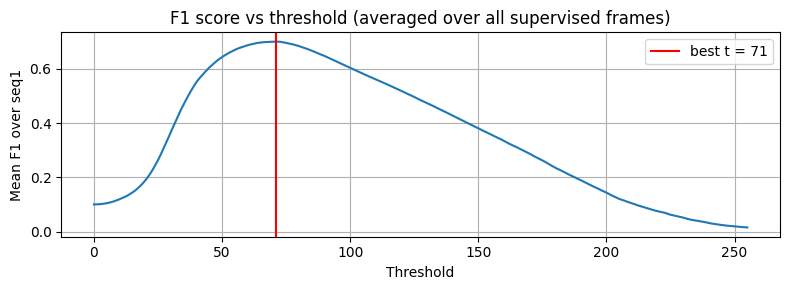

In [79]:
def F1_score(gt_mask, pred_mask):
    gt = gt_mask.astype(bool)
    pred = pred_mask.astype(bool)
    tp = (gt & pred).sum()
    return 2 * tp / (gt.sum() + pred.sum() + 1e-8)

# Pre computing of the foreground maps and gt masks for all frames in seq1
F_maps, S_masks = [], []

for no in seq1:
    I = imread(os.path.join(vid_path, f'frame{no:04d}.jpg')).astype(np.float32)
    F = np.sqrt(np.sum((I - B) ** 2, axis=2))  
    S = imread(os.path.join(gt_path, f'{no}.png')) > 0
    F_maps.append(F)
    S_masks.append(S)

# We sweep thresholds 0-255 and average F1 over all frames
thresholds = np.arange(0, 256)
mean_f1s   = [np.mean([F1_score(S, F > t) for F, S in zip(F_maps, S_masks)])
              for t in thresholds]

best_t = thresholds[np.argmax(mean_f1s)]
print(f'Best thresholds: {best_t}, mean F1 = {max(mean_f1s):.3f}')

plt.figure(figsize=(8,3))
plt.plot(thresholds, mean_f1s)
plt.axvline(best_t, color='red',label=f'best t = {best_t}')
plt.xlabel('Threshold')
plt.ylabel('Mean F1 over seq1')
plt.title('F1 score vs threshold (averaged over all supervised frames)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

399.03177 0.1503898


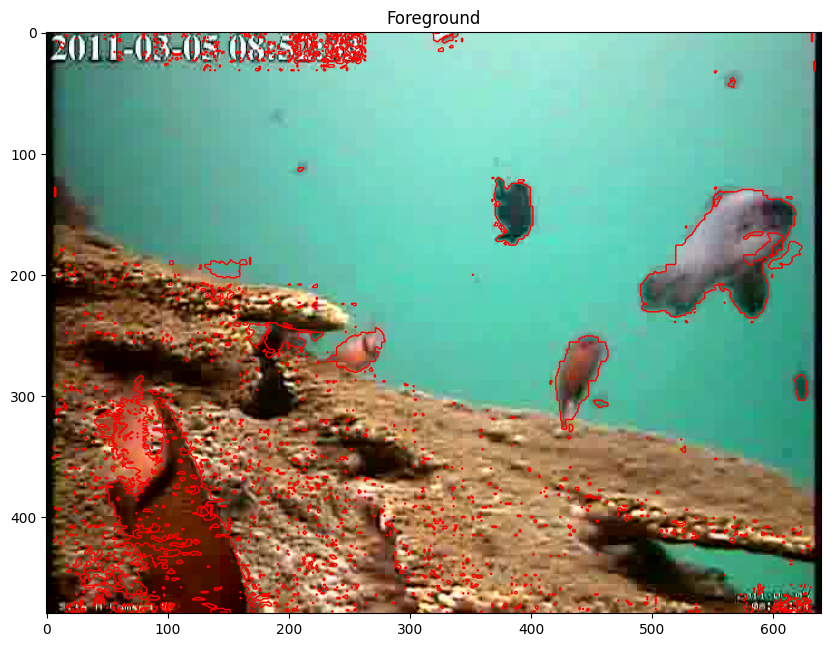

In [80]:
# trying remove the background
F = np.abs(I - B) #foreground = current frame - background
F = np.sqrt(np.sum((I-B)**2, axis=2)) # seconde method
print(F.max(),F.min())
fg_mask = F > 50 # create a mask for the foreground (binary image)
plt.figure(figsize=(10, 8))
plt.imshow(I/255) #apply a treshold
plt.contour(fg_mask, colors='r', linewidths=1) #draw the contour
plt.title('Foreground')
plt.show()

In [81]:
for f in range(*seq0):
    I = imread(os.path.join(vid_path, 'frame%04d.jpg' % f)).astype(np.float32)
    F = np.sqrt(np.sum((I - B) ** 2, axis=2))  # Foreground calculation
    S = imread(os.path.join(gt_path, '%d.png' % f)) > 0  # Ground truth mask
    print("Ground Truth Mask Shape:", S.shape, "Type:", S.dtype)
    print("Foreground Shape:", F.shape, "Type:", F.dtype)
    print("Current Frame Shape:", I.shape, "Type:", I.dtype)
    
    plt.figure(figsize=(10, 8))
    plt.subplot(1, 2, 1)
    plt.imshow(F, cmap='gray')  # Display foreground
    plt.title('Foreground')
    plt.subplot(1, 2, 2)
    plt.imshow(I / 255)  # Normalize and display the current frame
    plt.contour(S, colors='r', linewidths=1)  # Draw ground truth contour
    plt.title('Current Frame with Ground Truth Contour')
    plt.show()
    break  # Stop after one frame for testing

TypeError: range expected at most 3 arguments, got 21

Mean precision: 0.753
Mean Recall: 0.746
Mean F1: 0.744


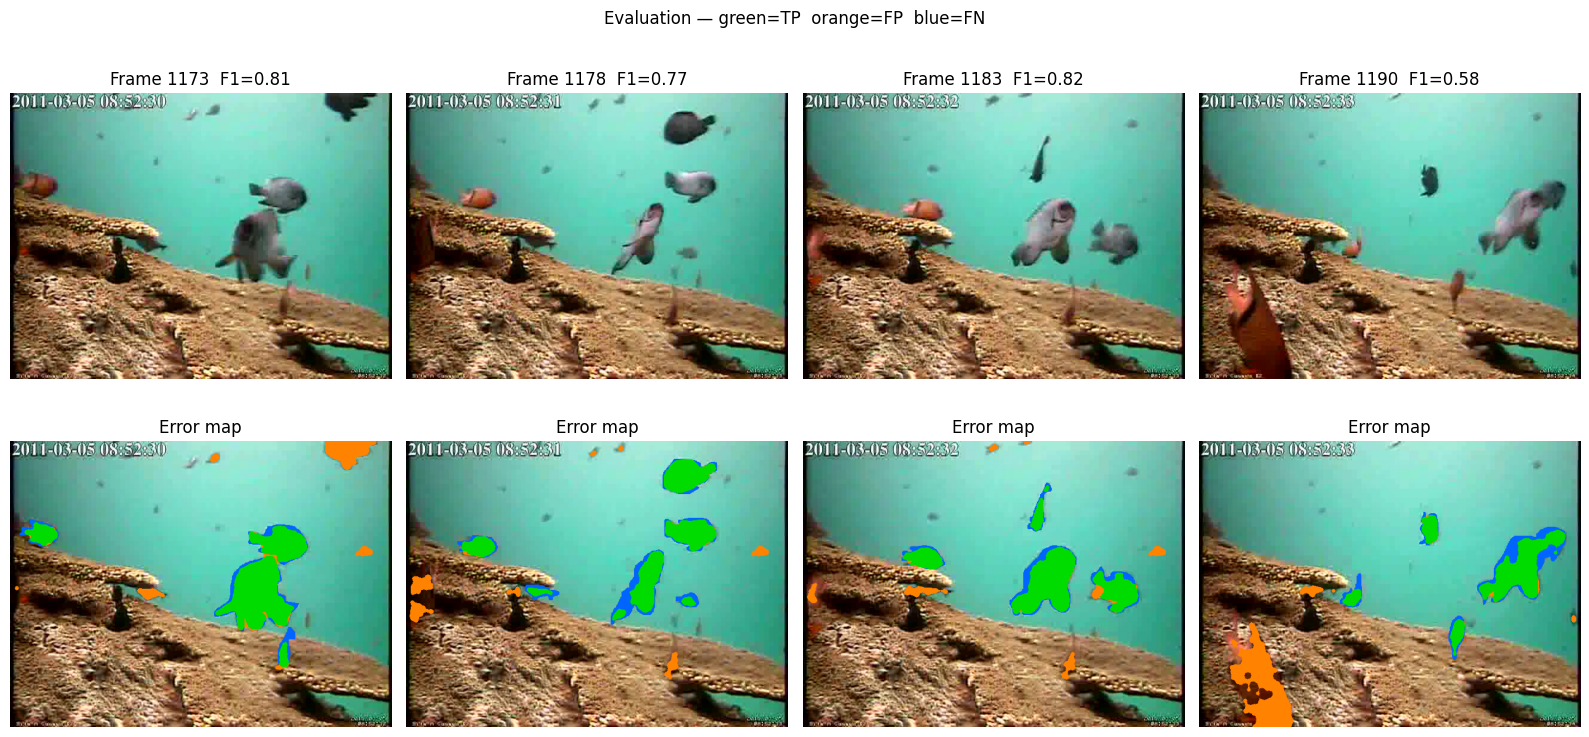

In [82]:
# clean the mask with morphological operation
from skimage.morphology import opening, closing, disk

def clean_mask(binary_mask):
    m = opening(binary_mask, disk(3))
    m = closing(m, disk(5))
    return m 

def precision_recall_F1(gt_mask, pred_mask):
    gt, pred = gt_mask.astype(bool), pred_mask.astype(bool)
    tp = (gt & pred).sum()
    fp = (~gt & pred).sum()
    fn = (gt & ~pred).sum()
    p = tp / (tp + fp +1e-8)
    r = tp / (tp + fn +1e-8)
    F1 = 2*tp / (2*tp + fp + fn + 1e-8)
    return p, r, F1

ps, rs, fs = [], [], []
for F, S in zip(F_maps, S_masks):
    P = clean_mask(F > best_t)
    p, r, f = precision_recall_F1(S, P)
    ps.append(p); rs.append(r); fs.append(f)

print(f'Mean precision: {np.mean(ps):.3f}')
print(f'Mean Recall: {np.mean(rs):.3f}')
print(f'Mean F1: {np.mean(fs):.3f}')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Evaluation — green=TP  orange=FP  blue=FN', fontsize=12)

B_vis = B.copy()
for col, idx in enumerate([0, 5, 10, 17]):
    no  = seq1[idx]
    I   = imread(os.path.join(vid_path, f'frame{no:04d}.jpg'))
    F, S = F_maps[idx], S_masks[idx]
    P   = clean_mask(F > best_t)

    overlay = I.copy()
    overlay[ P & ~S] = [255, 130,   0]   # FP orange
    overlay[~P &  S] = [  0, 100, 255]   # FN blue
    overlay[ P &  S] = [  0, 220,   0]   # TP green

    axes[0, col].imshow(I);            axes[0, col].set_title(f'Frame {no}  F1={fs[idx]:.2f}'); axes[0, col].axis('off')
    axes[1, col].imshow(overlay);      axes[1, col].set_title('Error map');                      axes[1, col].axis('off')

plt.tight_layout(); plt.show()

## Object tracking

1. Extract interesting features from the detected objects.
1. Suggest a method to recognise and track objects from one frame to the next frame.

Number of fish detected: 8


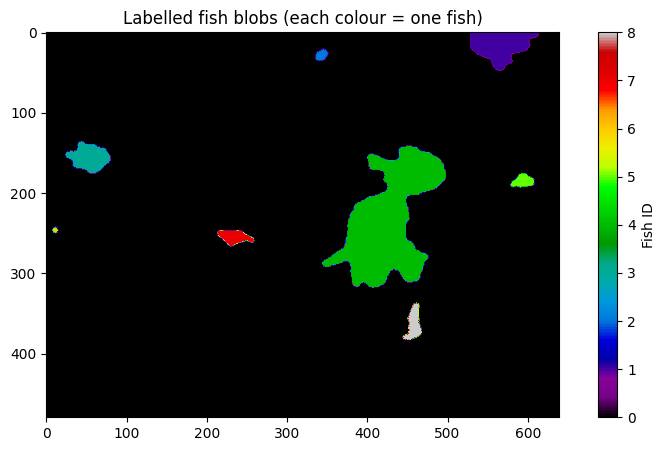

In [83]:

idx = 0
no  = seq1[idx]
I   = imread(os.path.join(vid_path, f'frame{no:04d}.jpg')).astype(np.float32)

P      = clean_mask(F_maps[idx] > best_t)
labels = label(P)   # each fish blob gets a unique integer ID

print(f'Number of fish detected: {labels.max()}')

plt.figure(figsize=(10, 5))
plt.imshow(labels, cmap='nipy_spectral')
plt.title('Labelled fish blobs (each colour = one fish)')
plt.colorbar(label='Fish ID')
plt.show()


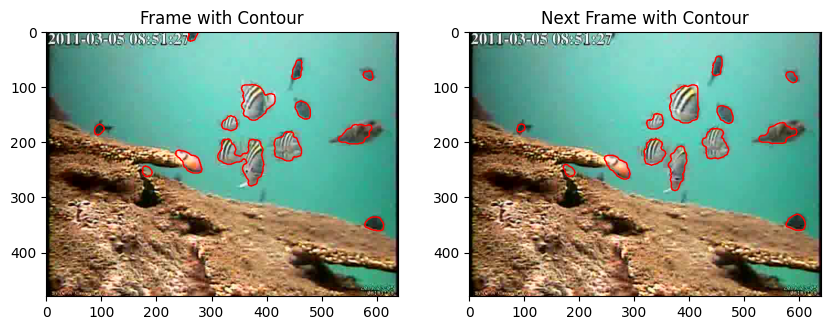

In [ ]:
I_next = imread(os.path.join(vid_path, 'frame%04d.jpg' % (f + 1))).astype(np.float32)
F_next = np.sqrt(np.sum((I_next - B) ** 2, axis=2))  # Foreground calculation
S_next = imread(os.path.join(gt_path, '%d.png' % (f + 1))) > 0  # Ground truth mask

P_next = opening(F_next > t, disk(5))
P_next = closing(P_next, disk(3))

labels_next = label(P_next)  # Label connected components for the next frame

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(I / 255)  # Normalize and display the current frame
plt.contour(P2, colors='r', linewidths=1)  # Draw contour of the current frame
plt.title('Frame with Contour')
plt.subplot(1, 2, 2)
plt.imshow(I_next / 255)  # Normalize and display the next frame
plt.contour(P_next, colors='r', linewidths=1)  # Draw contour of the next frame
plt.title('Next Frame with Contour')
plt.show()

1 [0]


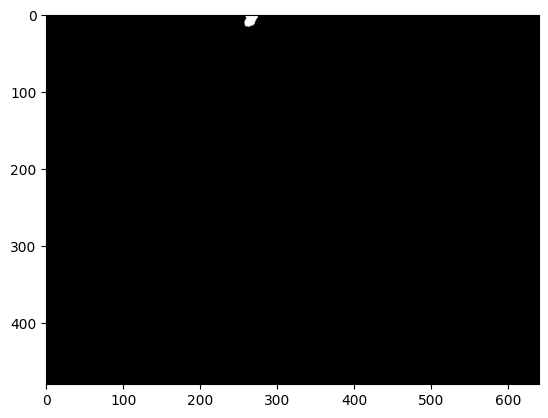

2 [0 1]


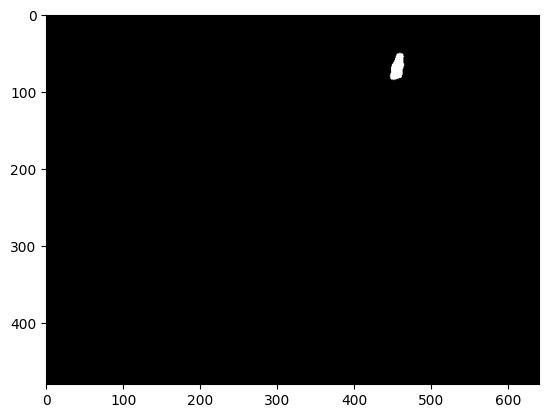

3 [0 2]


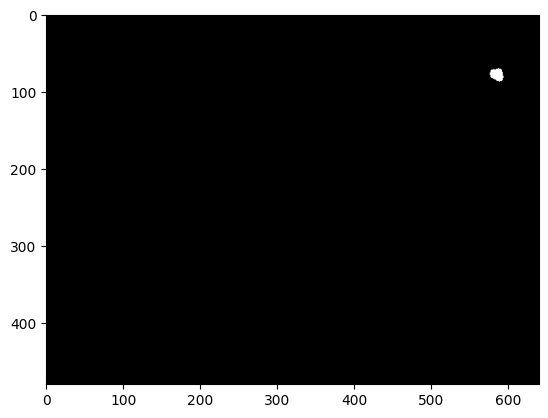

4 [0 3]


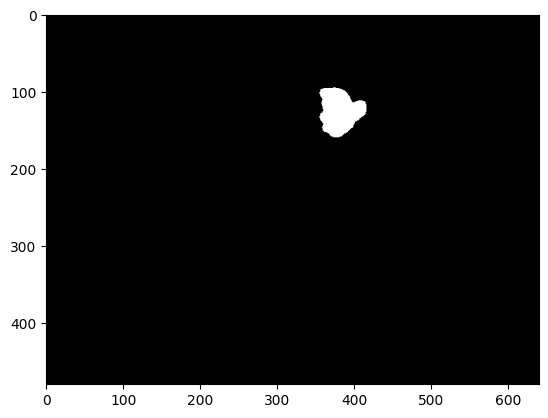

5 [0 4]


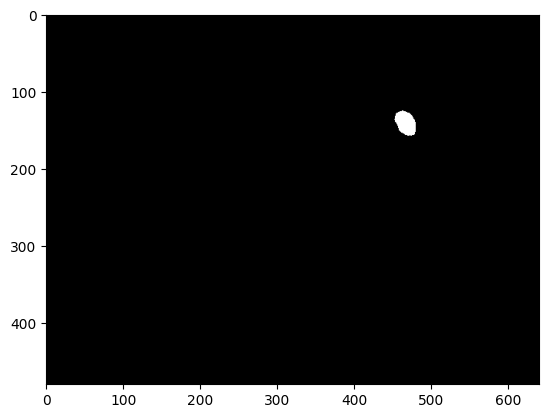

6 [0 5]


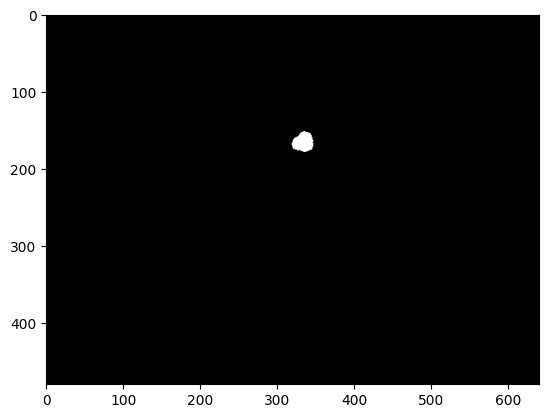

7 [0 7]


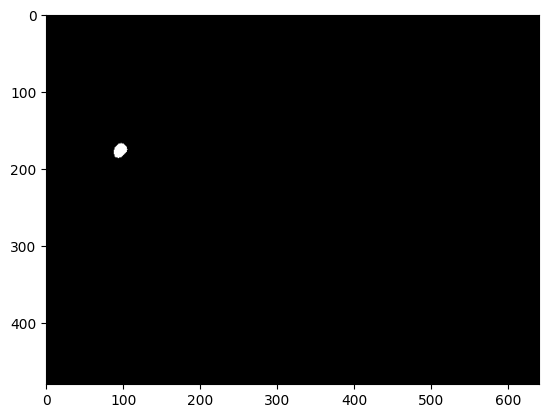

8 [0 6]


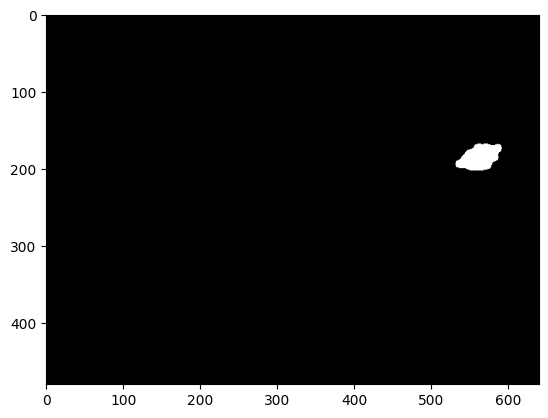

9 [0 8]


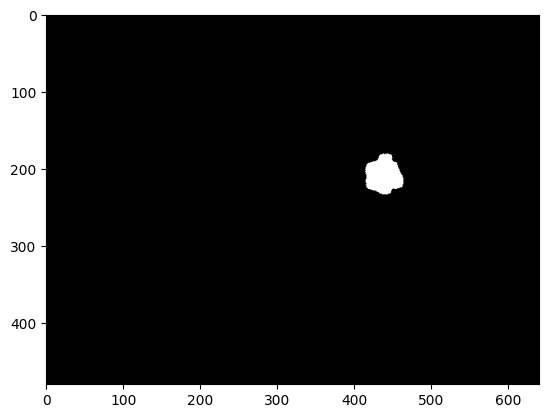

10 [ 0  9 10]


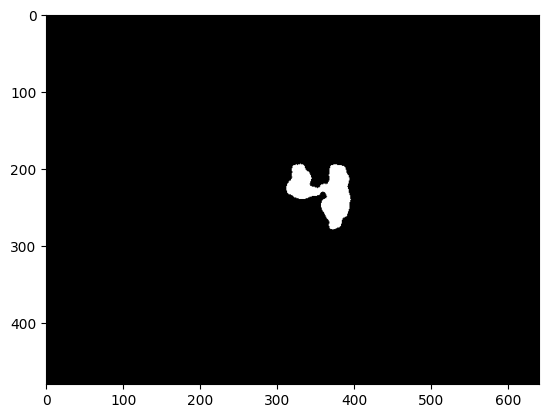

11 [ 0 11]


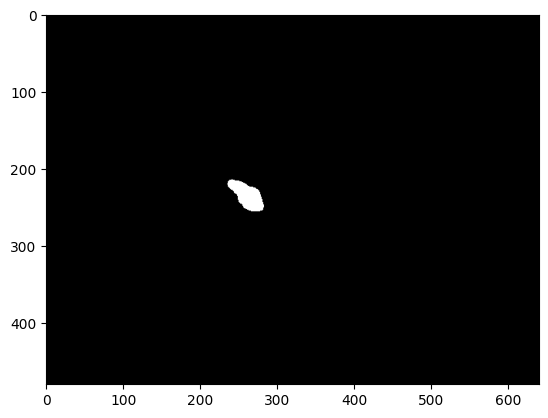

12 [12]


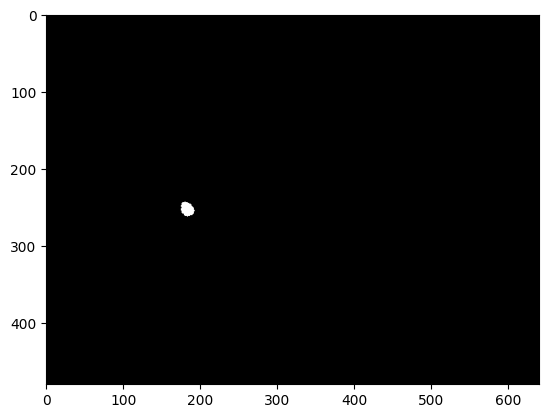

13 [ 0 13]


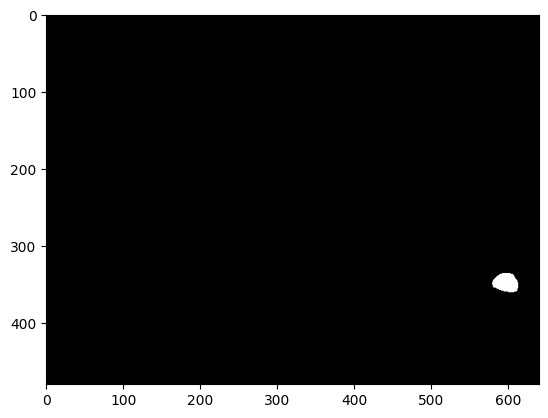

In [ ]:
for lab in range(1, labels.max() + 1):
    matching_objects = np.unique(labels_next[labels==lab])
    print(lab,matching_objects)
    plt.figure()
    plt.imshow(labels==lab,cmap='gray')
    plt.show()